In [1]:
import json
import os
from pathlib import Path

import contextily as cx
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from photutils.utils import make_random_cmap
from scipy.spatial.distance import jensenshannon, pdist, squareform
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

from urban_clusters.economic import get_distribution_df
from urban_clusters.plot import (
    plot_centroids,
    plot_cluster_distribution,
    plot_location_quotient,
    plot_num_jobs,
)
from urban_clusters.spatial import (
    cluster_points,
    cluster_points_weighted,
    generate_hulls,
    get_hotspot_mask,
    load_denue,
)

In [2]:
ZONE = "19.1.01"

In [3]:
data_path = Path(os.environ["DATA_PATH"])
generated_path = data_path / "generated"
figure_path = data_path / "docs" / "main" / "fig"
population_grids_path = Path(os.environ["POPULATION_GRIDS_PATH"])

results_path = Path("./results")
results_path.mkdir(exist_ok=True)

In [4]:
df_geom = gpd.read_file(
    population_grids_path / "final" / "framework" / "mun" / "2020.gpkg",
)

In [5]:
groups = [
    ["19039", "19019", "19048", "19018", "19021", "19046", "19026", "19006", "19031"],
    ["19031"],
    ["19009", "19041"],
    ["19004", "19049"],
    ["19045", "19012", "19025"],
]

# Spatial

In [ ]:
df_points = load_denue(generated_path / "denue" / "split" / f"{ZONE}.gpkg")
hotspot_mask = get_hotspot_mask(df_points, distance_band=500)

/Users/rodolfofigueroa/Documents/urban_clusters/.venv/lib/python3.11/site-packages/scipy/sparse/_data.py:128: RuntimeWarning: divide by zero encountered in power
  return self._with_data(data ** n)
/Users/rodolfofigueroa/Documents/urban_clusters/.venv/lib/python3.11/site-packages/libpysal/weights/util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 100 disconnected components.
 There are 26 islands with ids: 346, 2998, 4398, 9804, 11305, 16347, 36932, 54735, 55775, 61662, 62577, 64218, 66599, 72215, 72395, 80436, 80437, 80875, 101937, 117312, 119390, 122842, 126202, 138217, 152260, 153526.
  w = W(neighbors, weights, ids, **kwargs)
/Users/rodolfofigueroa/Documents/urban_clusters/.venv/lib/python3.11/site-packages/libpysal/weights/distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 100 disconnected components.
 There are 26 islands with ids: 346, 2998, 4398, 9804, 11305, 16347, 36932, 54735, 55775, 61662, 62577, 64218, 66599, 

('WARNING: ', 346, ' is an island (no neighbors)')
('WARNING: ', 2998, ' is an island (no neighbors)')
('WARNING: ', 4398, ' is an island (no neighbors)')
('WARNING: ', 9804, ' is an island (no neighbors)')
('WARNING: ', 11305, ' is an island (no neighbors)')
('WARNING: ', 16347, ' is an island (no neighbors)')
('WARNING: ', 36932, ' is an island (no neighbors)')
('WARNING: ', 54735, ' is an island (no neighbors)')
('WARNING: ', 55775, ' is an island (no neighbors)')
('WARNING: ', 61662, ' is an island (no neighbors)')
('WARNING: ', 62577, ' is an island (no neighbors)')
('WARNING: ', 64218, ' is an island (no neighbors)')
('WARNING: ', 66599, ' is an island (no neighbors)')
('WARNING: ', 72215, ' is an island (no neighbors)')
('WARNING: ', 72395, ' is an island (no neighbors)')
('WARNING: ', 80436, ' is an island (no neighbors)')
('WARNING: ', 80437, ' is an island (no neighbors)')
('WARNING: ', 80875, ' is an island (no neighbors)')
('WARNING: ', 101937, ' is an island (no neighbors)

/Users/rodolfofigueroa/Documents/urban_clusters/.venv/lib/python3.11/site-packages/esda/getisord.py:527: RuntimeWarning: invalid value encountered in divide
  z_scores = (statistic - expected_value) / np.sqrt(expected_variance)
/Users/rodolfofigueroa/Documents/urban_clusters/.venv/lib/python3.11/site-packages/esda/getisord.py:450: RuntimeWarning: invalid value encountered in divide
  self.z_sim = (self.Gs - self.EG_sim) / self.seG_sim


In [61]:
# Si pesar los puntos por número de empleos para el clustering espacial (2)
# o no (1)
METHOD = 2

# Parámetros para el clustering espacial
MIN_SPATIAL_SIZE = 10
EPSILON = 50

In [62]:
if METHOD == 1:
    clusters = cluster_points(
        df_points,
        hdbscan_params={
            "min_cluster_size": MIN_SPATIAL_SIZE,
            "cluster_selection_epsilon": EPSILON,
        },
    )
elif METHOD == 2:
    clusters = cluster_points_weighted(
        df_points,
        hotspot_mask=hotspot_mask,
        hdbscan_params={
            "min_cluster_size": MIN_SPATIAL_SIZE,
            "cluster_selection_epsilon": EPSILON,
        },
    )
df_points = df_points.assign(spatial_cluster=clusters)

/Users/rodolfofigueroa/Documents/urban_clusters/.venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/rodolfofigueroa/Documents/urban_clusters/.venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [63]:
df_polygons = generate_hulls(
    df_points,
    cluster_col="spatial_cluster",
    buffer=0,
).set_index("spatial_cluster")

# Economic

In [64]:
df_counts = get_distribution_df(
    df_points,
    level=3,
    normalize=True,
    cluster_col="spatial_cluster",
)
distance_mat = squareform(pdist(df_counts.to_numpy(), metric=jensenshannon))

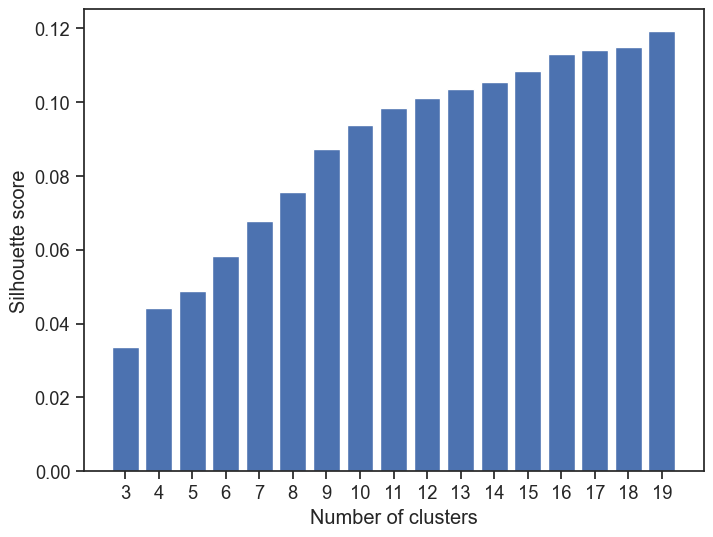

In [65]:
x, y = [], []
for n_clusters in range(3, 20):
    model = AgglomerativeClustering(
        metric="precomputed",
        linkage="complete",
        n_clusters=n_clusters,
    )
    clusters = model.fit_predict(distance_mat).astype(float)
    score = silhouette_score(distance_mat, clusters, metric="precomputed")
    x.append(n_clusters)
    y.append(score)

fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(x, y)
ax.set_xlabel("Number of clusters")
ax.set_ylabel("Silhouette score")
ax.set_xticks(x)
_ = ax.set_xticklabels(x)

In [66]:
NUM_CLUSTERS = 8

In [67]:
labels = AgglomerativeClustering(
    metric="precomputed",
    linkage="complete",
    n_clusters=NUM_CLUSTERS,
).fit_predict(distance_mat)
cluster_label_map = dict(zip(df_counts.index, labels, strict=True))

df_points = df_points.assign(
    economic_cluster=lambda df: df["spatial_cluster"].map(cluster_label_map),
)

df_polygons = df_polygons.assign(
    economic_cluster=lambda df: df.index.map(cluster_label_map),
)

In [68]:
metadata = {
    "method": METHOD,
    "min_spatial_size": MIN_SPATIAL_SIZE,
    "eps": EPSILON,
    "num_economic_clusters": NUM_CLUSTERS,
}

# Plots

In [69]:
max_idx, curr_idx = 0, None
for subdir in results_path.iterdir():
    idx = int(subdir.stem.split("_")[-1])
    max_idx = max(max_idx, idx)

    with open(subdir / "metadata.json") as f:
        open_metadata = json.load(f)
        if open_metadata == metadata:
            curr_idx = idx
            break

if curr_idx is None:
    curr_idx = max_idx + 1

subdir = results_path / f"run_{curr_idx}"
subdir.mkdir(parents=True, exist_ok=True)

with open(subdir / "metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)

subfigure_path = subdir / "figures"
subfigure_path.mkdir(parents=True, exist_ok=True)

## Map

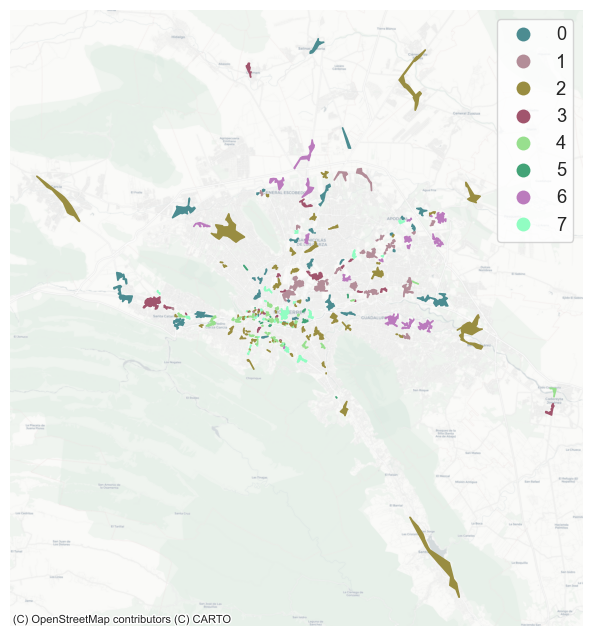

In [70]:
sns.set_theme(style="ticks", font_scale=1.2)
fig, ax = plt.subplots(figsize=(8, 8))
(
    df_polygons.assign(geometry=lambda df: df["geometry"].buffer(100)).plot(
        column="economic_cluster",
        ax=ax,
        cmap=make_random_cmap(len(df_polygons["economic_cluster"].unique()), seed=1),
        lw=0,
        legend=True,
        categorical=True,
    )
)
ax.axis("off")
cx.add_basemap(ax, crs=df_polygons.crs, zoom=12, source=cx.providers.CartoDB.Positron)
fig.savefig(subfigure_path / "clusters_map.jpg", bbox_inches="tight", dpi=300)

## Counts

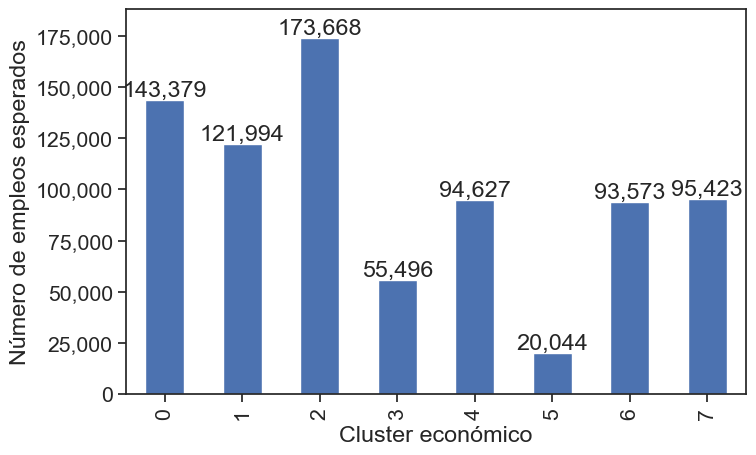

In [71]:
sns.set_theme(style="ticks", font_scale=1.4)
fig, ax = plt.subplots(figsize=(8, 5))
plot_num_jobs(df_points, ax=ax)
ax.set_ylim(0, ax.get_ylim()[1] * 1.03)
fig.savefig(subfigure_path / "num_jobs.jpg", bbox_inches="tight", dpi=300)

## Location quotient

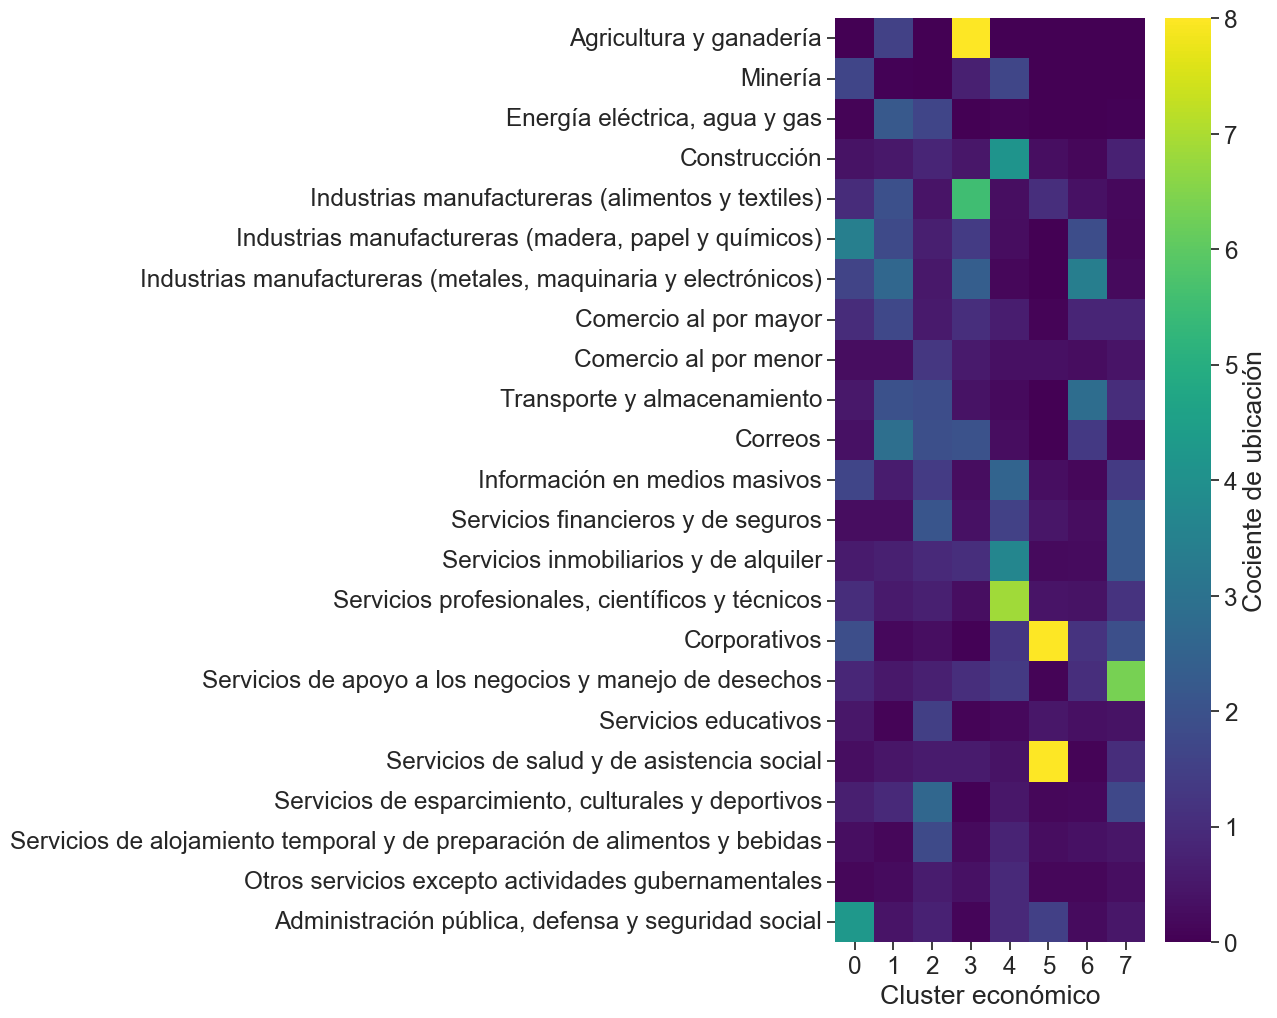

In [72]:
sns.set_theme(style="ticks", font_scale=1.6)
fig, ax = plt.subplots(figsize=(5, 12))
plot_location_quotient(df_points, ax=ax, level=2, heatmap_kws={"vmax": 8})
fig.savefig(subfigure_path / "location_quotient.jpg", bbox_inches="tight", dpi=300)

## Distribution

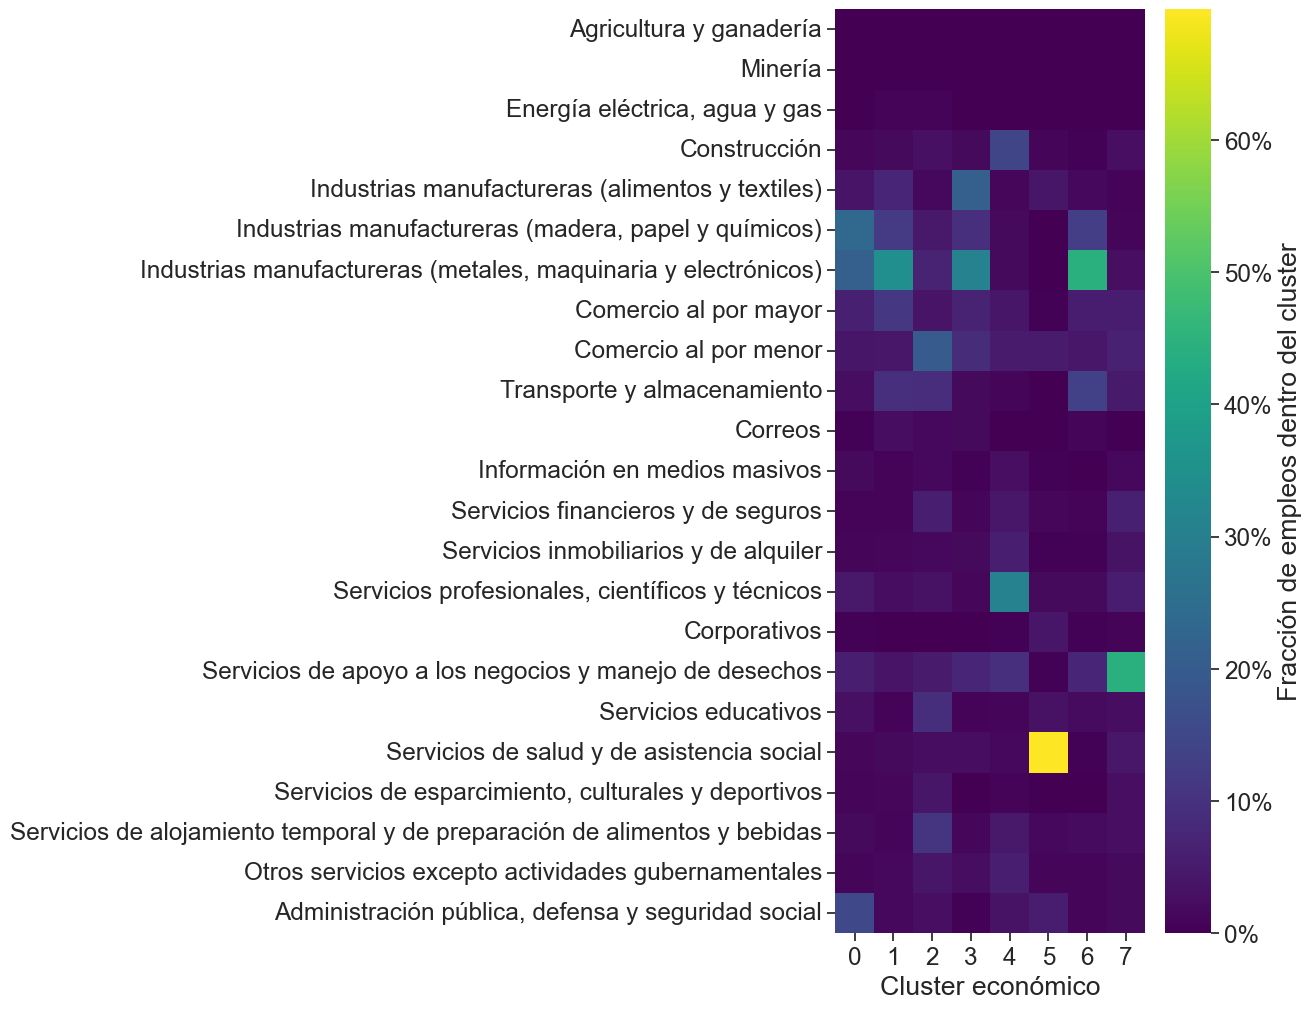

In [73]:
sns.set_theme(style="ticks", font_scale=1.6)
fig, ax = plt.subplots(figsize=(5, 12))
plot_cluster_distribution(df_points, ax=ax, level=2)
fig.savefig(subfigure_path / "cluster_distribution.jpg", bbox_inches="tight", dpi=300)

## Centroid

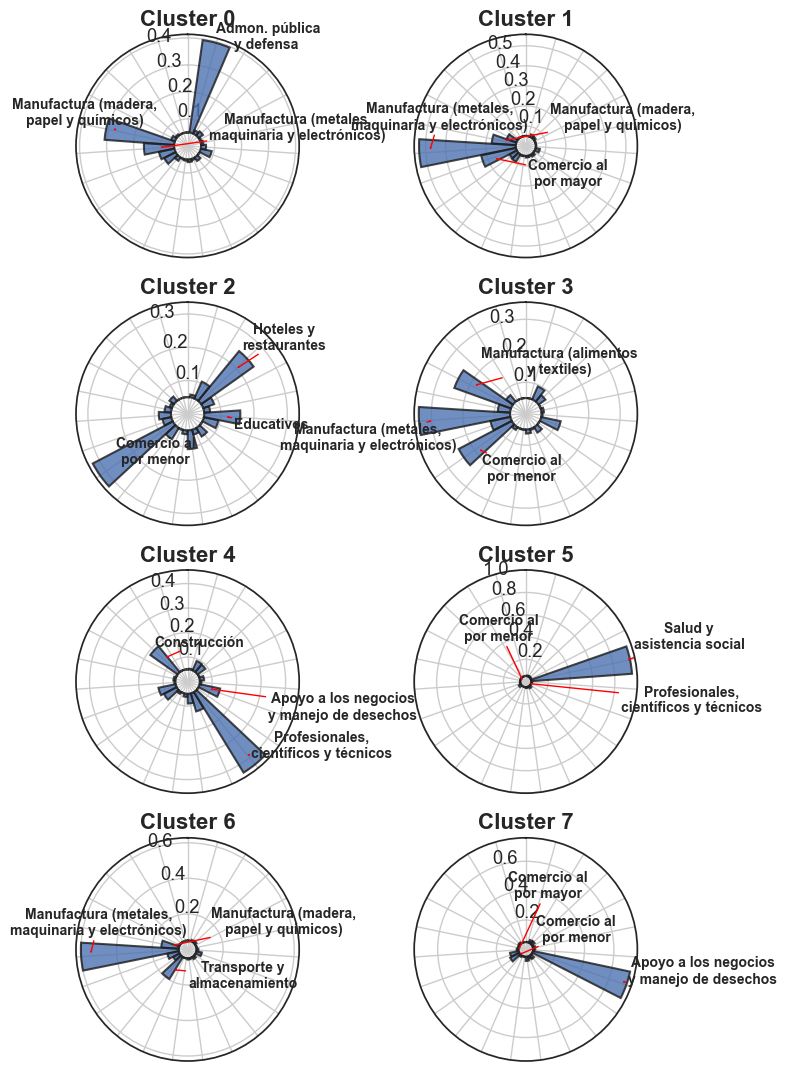

In [74]:
sns.set_theme(style="ticks", font_scale=1.2)
fig, _ = plot_centroids(df_points, level=2, annotate_top=True)
fig.savefig(subfigure_path / "centroids.jpg", bbox_inches="tight", dpi=300)

# Files

In [75]:
df_points.to_crs("EPSG:4326").to_file(subdir / "points.gpkg")
df_polygons.to_crs("EPSG:4326").to_file(subdir / "polygons.gpkg")